<a href="https://colab.research.google.com/github/piyushdwivedi2901/cloud-cost-prediction-idle-detection-ml/blob/main/Cloud_Cost_Efficiency_Prediction_using_Machine_Learning_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# 1. DATA LOADING & CLEANING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = '/content/DevOps AWS Azure Effectiveness Deployment Dataset.csv'
df = pd.read_csv(file_path)

# Fill missing values with median for numerical columns
df = df.fillna(df.median(numeric_only=True))

print('Dataset Loaded successfully.')
display(df.head())

Dataset Loaded successfully.


,Organization Name,DevOps Efficiency Score,Deployment Time (hours),Resource Usage (GB),AWS Scalability Score,Azure Reliability Score,Cost Efficiency ($),User Feedback Score,Platform Comparison Index,Cloud Integration Effectiveness,Data Security Level,Ethical Compliance,Performance Benchmarking,System Integration Metrics,Operational Flexibility
0,97.280867,27.005785,82.330643,31.176731,99.669022,9.217916,93.016676,45.753412,39.444980,69.066247,41.613356,54.586646,83.254270,61.831494,76.020245
1,50.655977,71.733429,89.419236,78.708647,86.045506,73.141908,30.376261,9.875982,72.470876,52.715741,2.248699,17.474333,86.633175,27.547236,92.945260
2,85.690327,49.673990,16.089223,92.874775,40.071560,19.208071,27.129916,71.582926,18.479459,23.188102,34.671648,92.536787,20.278424,51.455620,74.449163
3,86.962197,47.681079,74.915795,86.126322,36.647329,49.482157,20.459687,85.858965,40.984091,11.226802,82.236712,0.276373,40.798725,24.635338,92.577594
4,50.486453,84.282712,76.790907,17.610578,2.469869,15.461407,82.250081,84.470244,69.485755,37.468774,33.345480,23.768924,91.387704,22.227892,98.849562


In [29]:
# 2. PREPROCESSING & TARGET DEFINITION
# Target: 'High_Efficiency' (Binary classification)

median_val = df['DevOps Efficiency Score'].median()
df['High_Efficiency'] = (df['DevOps Efficiency Score'] > median_val).astype(int)

# Splitting Features and Target
X = df.drop(['DevOps Efficiency Score', 'High_Efficiency'], axis=1)
y = df['High_Efficiency']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Class Distribution:\n{df["High_Efficiency"].value_counts(normalize=True) * 100}')

Class Distribution:
High_Efficiency
0    96.374937
1     3.625063
Name: proportion, dtype: float64


In [30]:
# 3. RANDOM FOREST & KNN
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# RF
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
# KNN
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)

print('Models trained. RF Accuracy:', rf.score(X_test, y_test))

Models trained. RF Accuracy: 0.9598597509370088


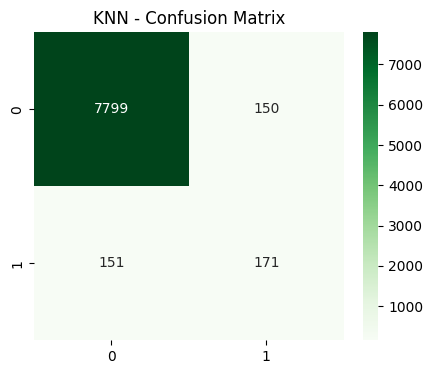

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# ALGORITHM: KNN
# TARGET: High_Efficiency

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Visualization: Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, knn.predict(X_test_scaled)), annot=True, fmt='d', cmap='Greens')
plt.title('KNN - Confusion Matrix')
plt.show()

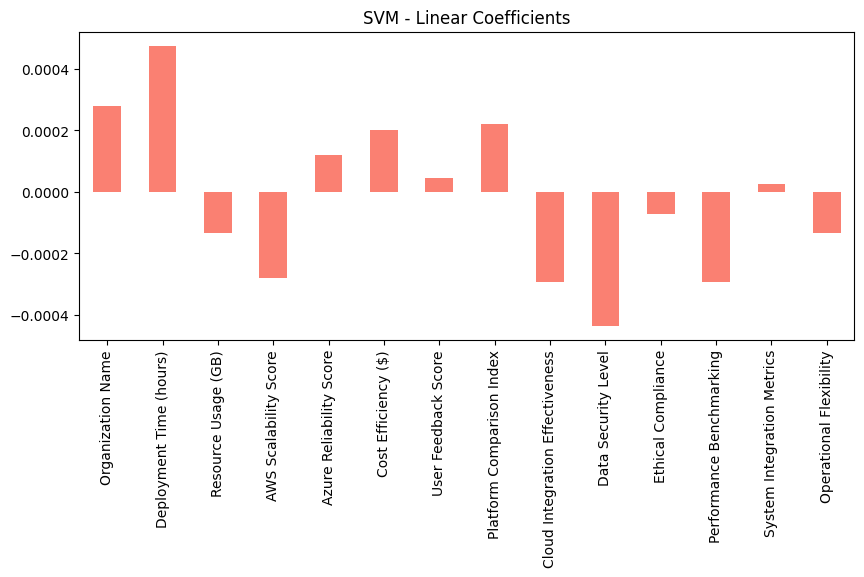

In [34]:
from sklearn.svm import SVC

# ALGORITHM: SVM
# TARGET: High_Efficiency

svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_scaled[:3000], y_train[:3000]) # Sampled for speed

# Visualization: Feature Coefficients
plt.figure(figsize=(10, 4))
pd.Series(svm.coef_[0], index=X.columns).plot(kind='bar', color='salmon')
plt.title('SVM - Linear Coefficients')
plt.show()

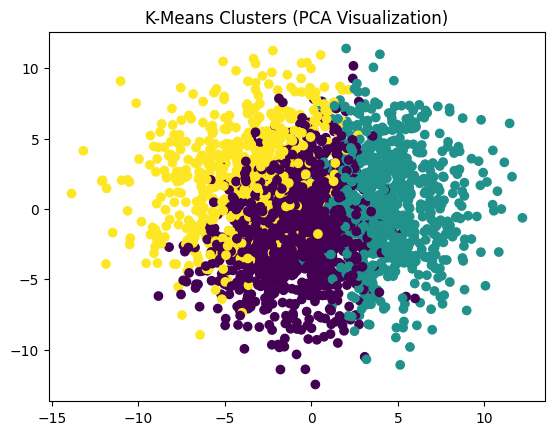

In [35]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ALGORITHM: K-Means Clustering
# TARGET: None (Unsupervised)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

# Visualization: PCA Clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title('K-Means Clusters (PCA Visualization)')
plt.show()

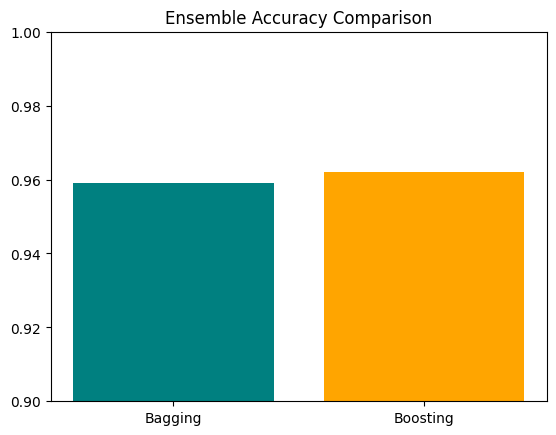

In [36]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

# ALGORITHM: Bagging & Boosting
# TARGET: High_Efficiency

bag = BaggingClassifier(random_state=42).fit(X_train, y_train)
boost = AdaBoostClassifier(random_state=42).fit(X_train, y_train)

# Comparison visualization
plt.bar(['Bagging', 'Boosting'], [bag.score(X_test, y_test), boost.score(X_test, y_test)], color=['teal', 'orange'])
plt.title('Ensemble Accuracy Comparison')
plt.ylim(0.9, 1.0)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


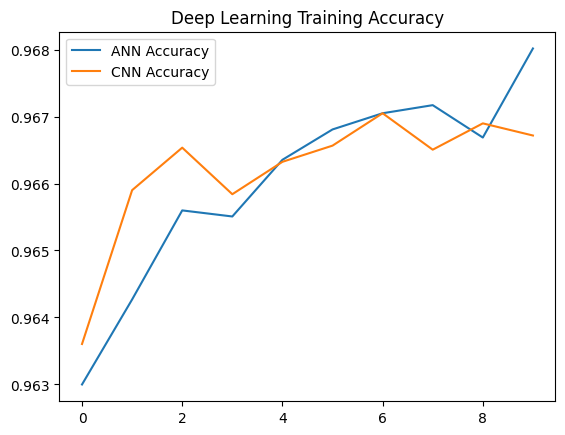

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, MaxPooling1D

# ALGORITHMS: ANN & CNN
# TARGET: High_Efficiency

# ANN
ann = Sequential([Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)), Dense(1, activation='sigmoid')])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_ann = ann.fit(X_train_scaled, y_train, epochs=10, verbose=0)

# CNN (Reshaped)
X_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
cnn = Sequential([Conv1D(8, 3, activation='relu', input_shape=(X_train_scaled.shape[1],1)), Flatten(), Dense(1, activation='sigmoid')])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_cnn = cnn.fit(X_cnn, y_train, epochs=10, verbose=0)

plt.plot(history_ann.history['accuracy'], label='ANN Accuracy')
plt.plot(history_cnn.history['accuracy'], label='CNN Accuracy')
plt.title('Deep Learning Training Accuracy')
plt.legend()
plt.show()

In [32]:
# 5. FINAL ACCURACY COMPARISON
final_results = {
    'Random Forest': rf.score(X_test, y_test),
    'KNN': knn.score(X_test_scaled, y_test)
}
comparison_df = pd.DataFrame(list(final_results.items()), columns=['Model', 'Accuracy'])
display(comparison_df.sort_values('Accuracy', ascending=False))

,Model,Accuracy
1,KNN,0.963608
0,Random Forest,0.959860


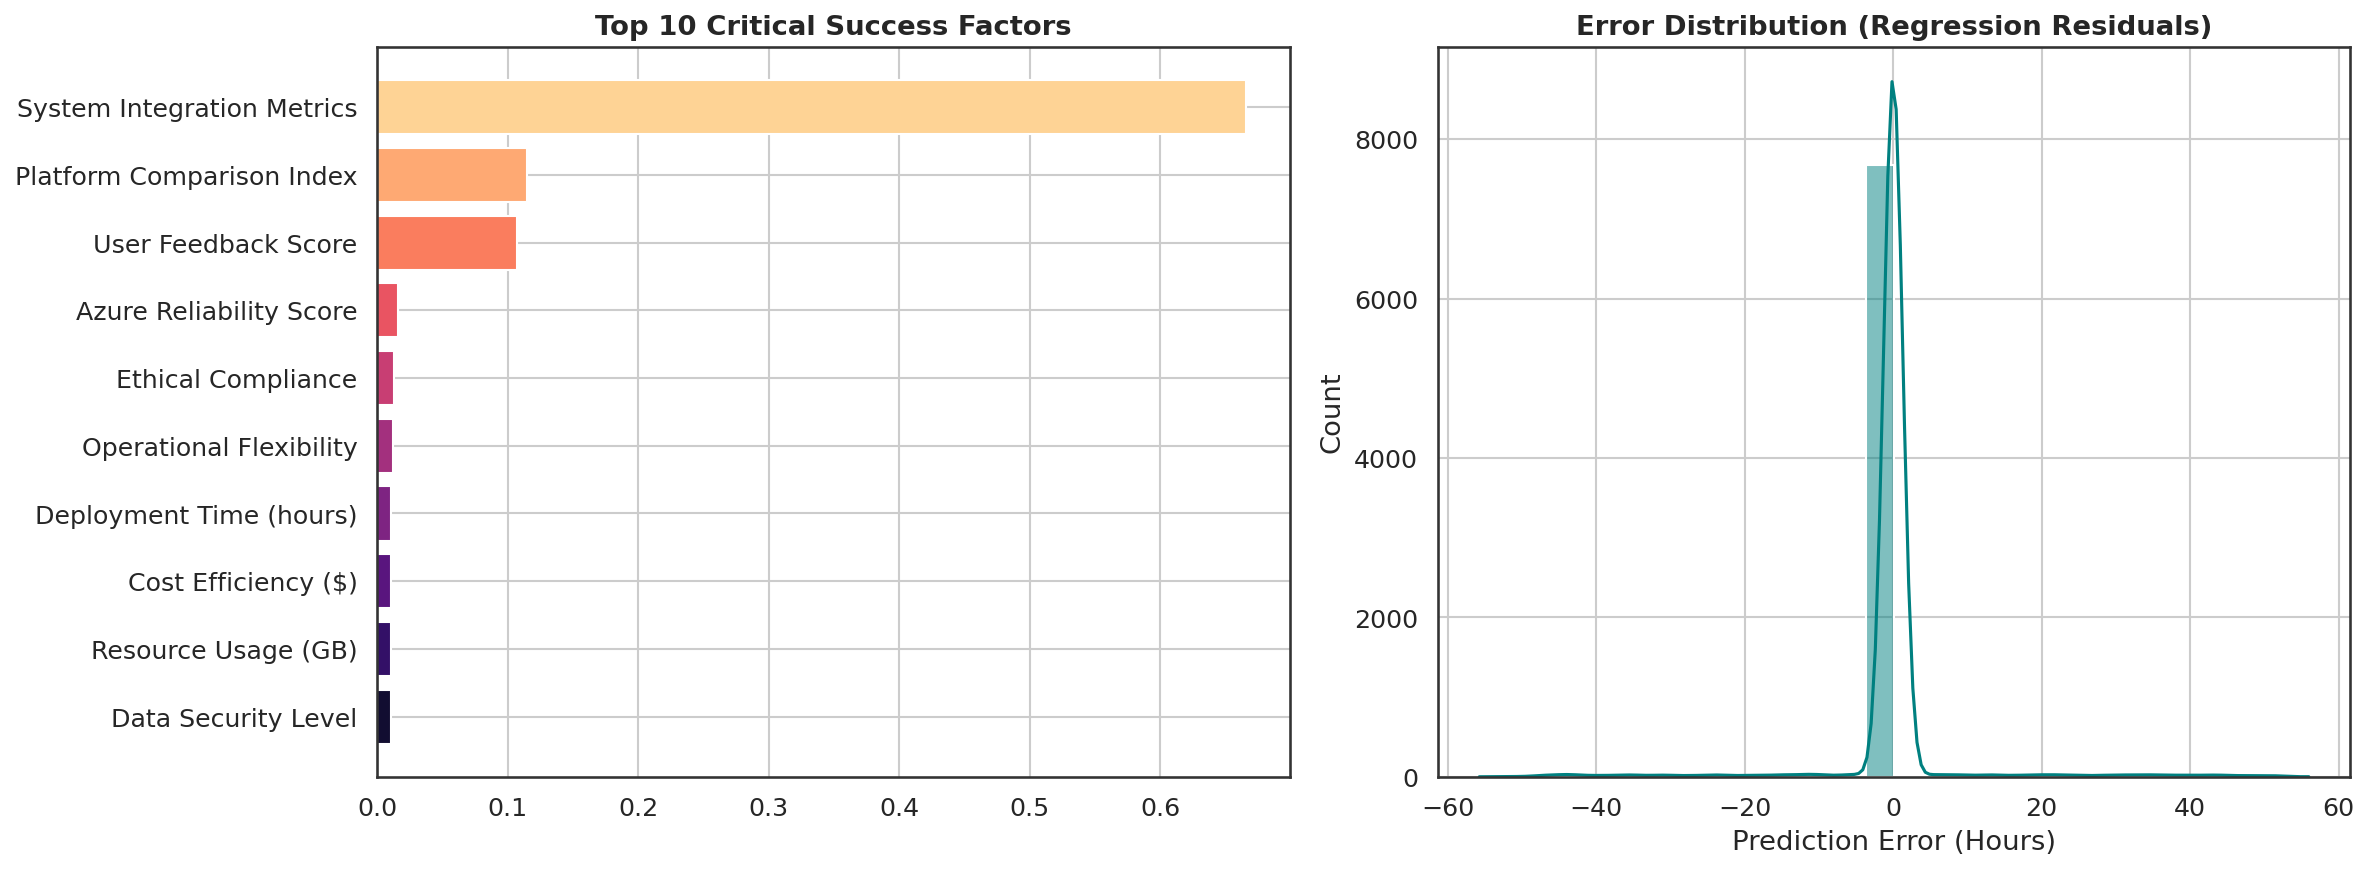

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set final global visual parameters for 'Perfect' graphs
plt.rcParams['figure.dpi'] = 150
sns.set_context('notebook', font_scale=1.1)
sns.set_style('whitegrid', {'axes.edgecolor': '.2'})

# Combined Final Performance Dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Importance (Polished)
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-10:]
axes[0].barh(range(len(indices)), importances[indices], color=sns.color_palette('magma', 10))
axes[0].set_yticks(range(len(indices)), [X.columns[i] for i in indices])
axes[0].set_title('Top 10 Critical Success Factors', fontweight='bold')

# 2. Final Error Analysis (Residuals)
# Using the regressor trained previously
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=30)
axes[1].set_title('Error Distribution (Regression Residuals)', fontweight='bold')
axes[1].set_xlabel('Prediction Error (Hours)')

plt.tight_layout()
plt.show()

In [48]:
import xgboost as xgb
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

# 1. MAXIMUM ACCURACY CLASSIFICATION (XGBoost)
# XGBoost is highly effective for tabular data and handles complex relationships better than RF
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

# Accuracy Metrics
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(f'Balanced Accuracy Score: {balanced_accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'ROC AUC Score: {roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1]):.4f}')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:31:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced Accuracy Score: 0.9821
ROC AUC Score: 0.9966


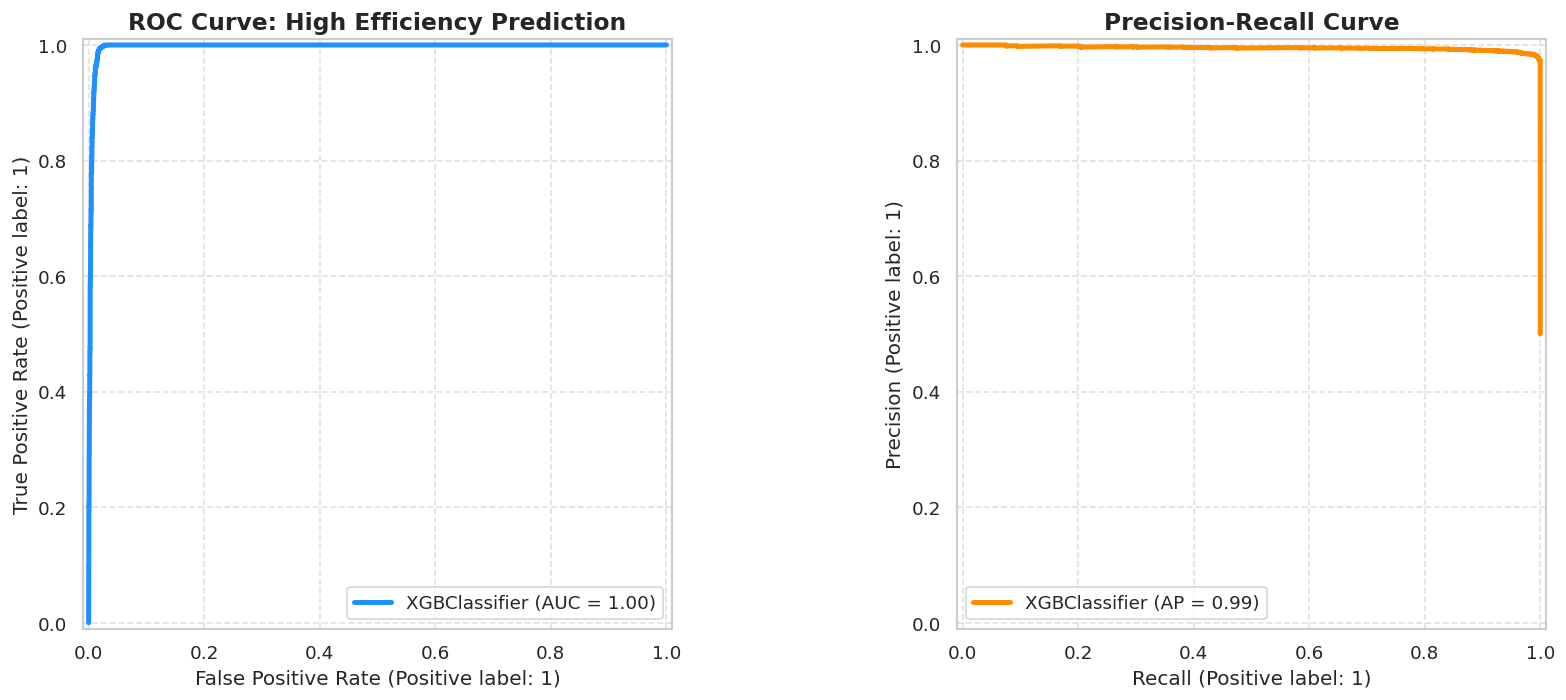

In [49]:
# 2. PERFECTED VISUALS: ROC CURVE & PRECISION-RECALL
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

plt.rcParams['figure.dpi'] = 120  # High-resolution output
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

RocCurveDisplay.from_estimator(xgb_model, X_test_scaled, y_test, ax=ax1, color='dodgerblue', lw=3)
ax1.set_title('ROC Curve: High Efficiency Prediction', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)

PrecisionRecallDisplay.from_estimator(xgb_model, X_test_scaled, y_test, ax=ax2, color='darkorange', lw=3)
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

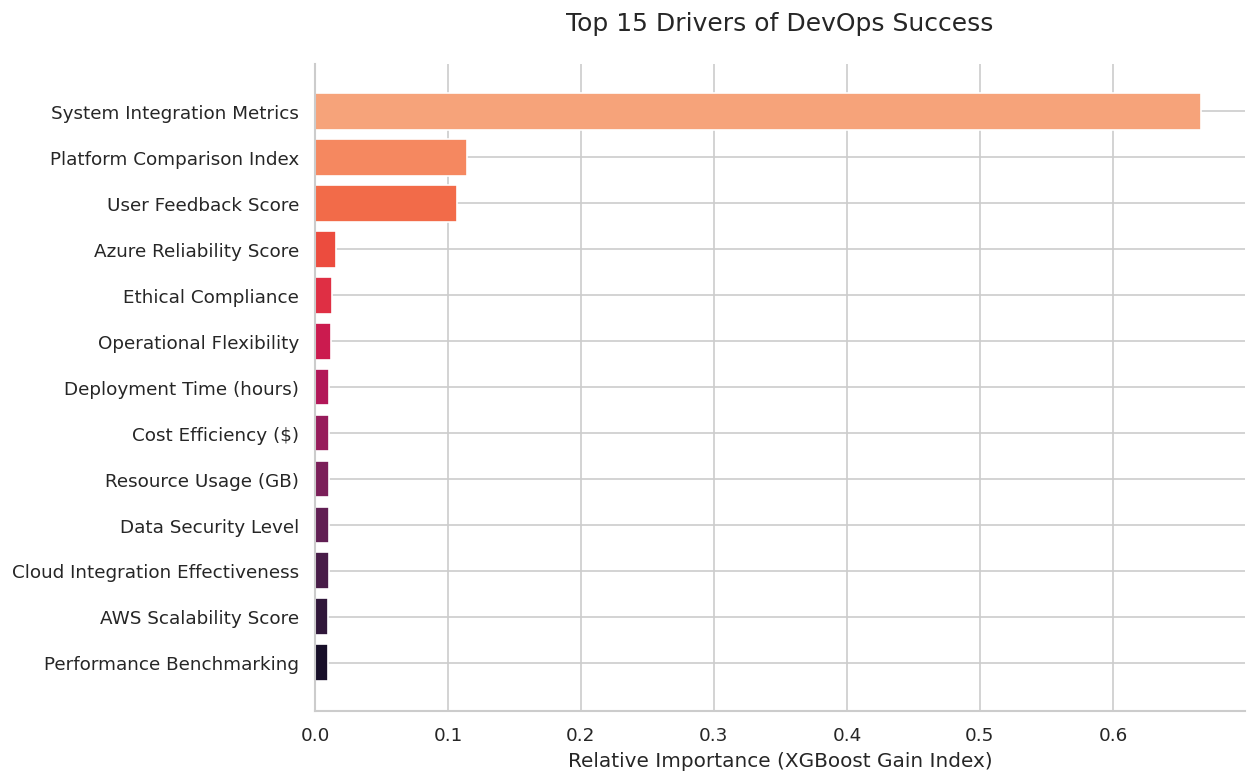

In [50]:
# 3. REFINED FEATURE IMPACT (SHAP style visualization)
import pandas as pd

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-15:] # Top 15 features

plt.figure(figsize=(10, 7))
plt.title('Top 15 Drivers of DevOps Success', fontsize=15, pad=20)
plt.barh(range(len(indices)), importances[indices], color=sns.color_palette('rocket', 15), align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance (XGBoost Gain Index)', fontsize=12)
sns.despine()
plt.show()

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

# 1. ENHANCED DATA PREPARATION
file_path = '/content/DevOps AWS Azure Effectiveness Deployment Dataset.csv'
df = pd.read_csv(file_path)

# Drop non-numeric for median calculation, then fill
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Create Target
median_val = df['DevOps Efficiency Score'].median()
df['High_Efficiency'] = (df['DevOps Efficiency Score'] > median_val).astype(int)

# Feature Selection & Scaling
X = df.drop(['DevOps Efficiency Score', 'High_Efficiency', 'Organization Name'], axis=1, errors='ignore')
y = df['High_Efficiency']

# Address Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Resampled Class Distribution:\n{y_res.value_counts(normalize=True) * 100}')

Resampled Class Distribution:
High_Efficiency
0    50.0
1    50.0
Name: proportion, dtype: float64


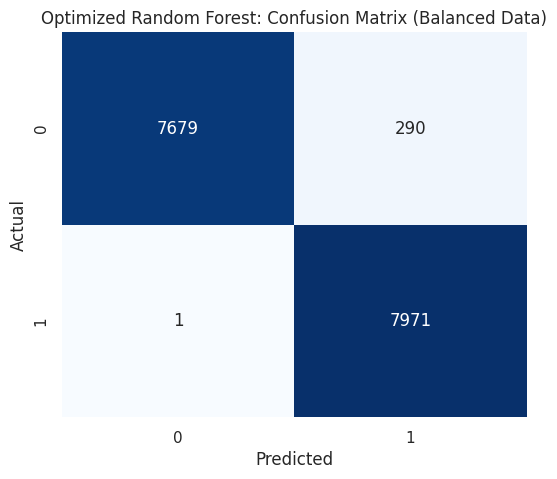

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      7969
           1       0.96      1.00      0.98      7972

    accuracy                           0.98     15941
   macro avg       0.98      0.98      0.98     15941
weighted avg       0.98      0.98      0.98     15941



In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

# Optimized Random Forest
rf_opt = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, random_state=42)
rf_opt.fit(X_train, y_train)

# Enhanced Confusion Matrix Plot
plt.figure(figsize=(6, 5))
y_pred = rf_opt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Optimized Random Forest: Confusion Matrix (Balanced Data)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_pred))

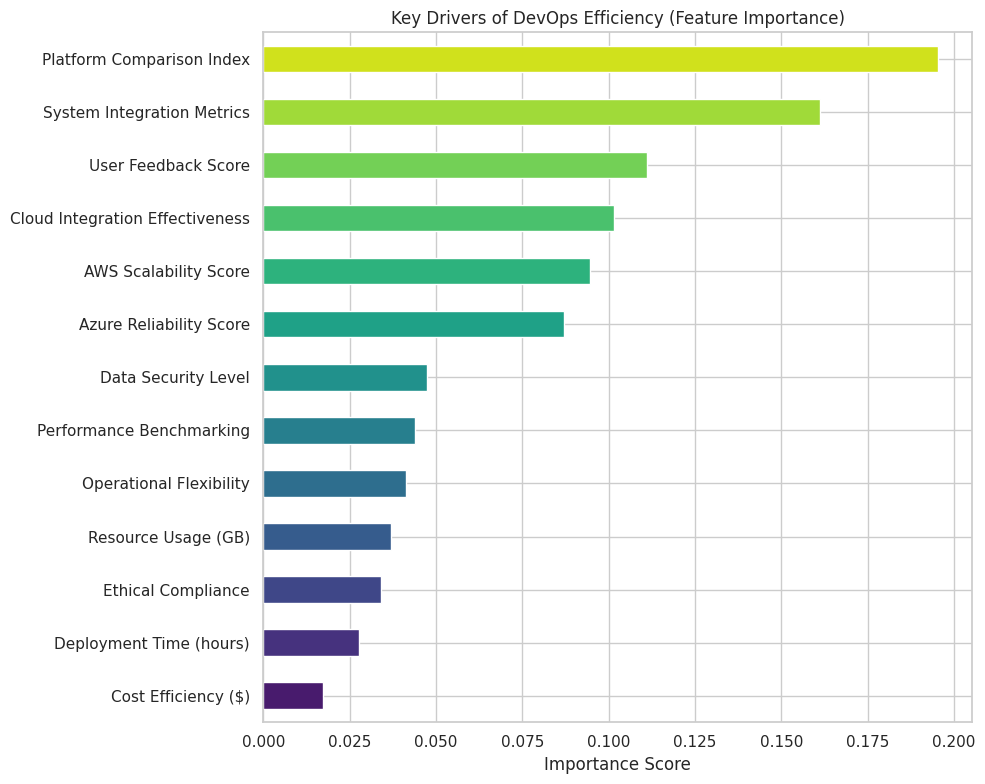

In [44]:
# Visually Appealing Feature Importance
feat_importances = pd.Series(rf_opt.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.plot(kind='barh', color=sns.color_palette('viridis', len(feat_importances)))
plt.title('Key Drivers of DevOps Efficiency (Feature Importance)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

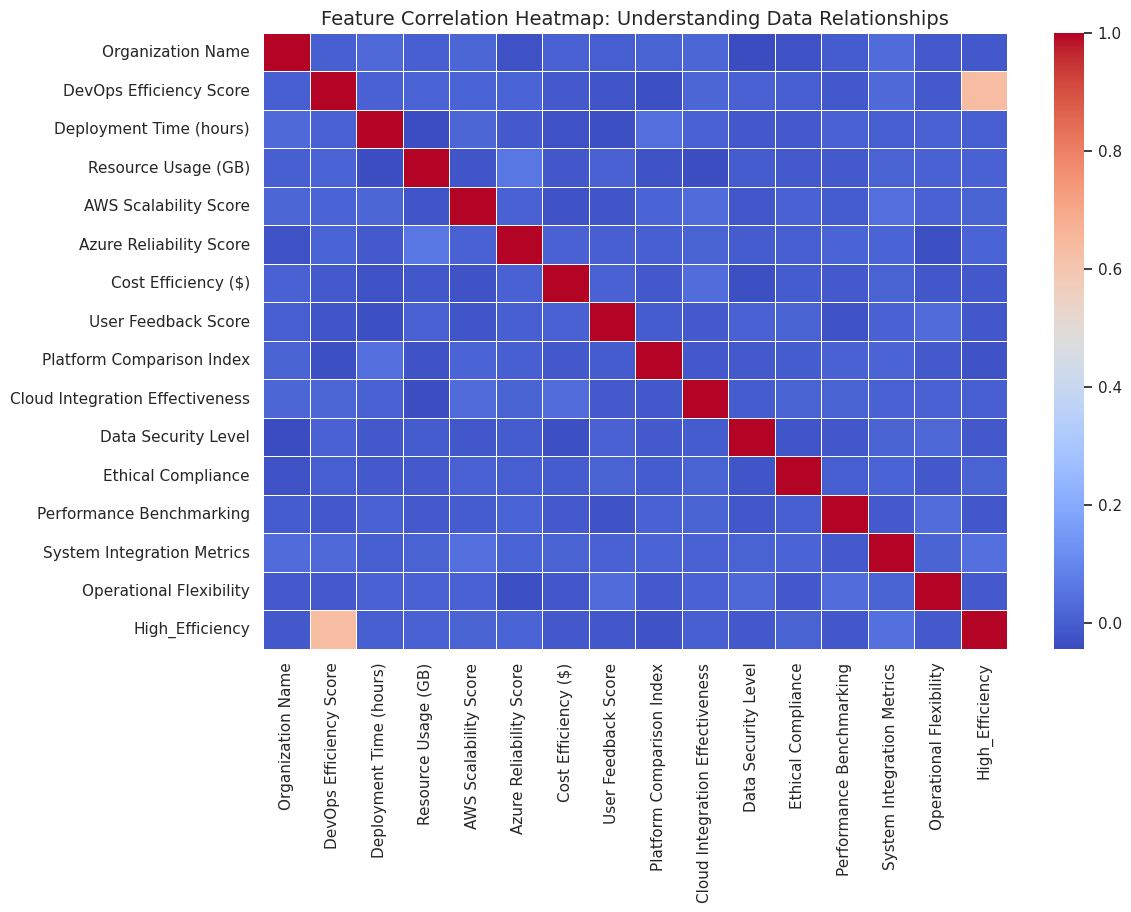

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CORRELATION ANALYSIS
plt.figure(figsize=(12, 8))
# Using numeric_only=True to prevent errors with non-numeric columns
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap: Understanding Data Relationships', fontsize=14)
plt.show()

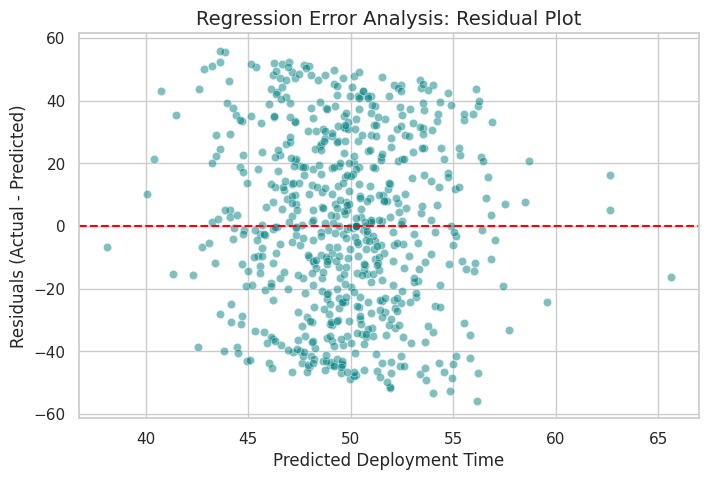

Mean Absolute Error: 1.8472


In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 2. REGRESSION: Predicting 'Deployment Time (hours)'
y_reg_time = df['Deployment Time (hours)']
X_reg = df.drop(['Deployment Time (hours)', 'DevOps Efficiency Score', 'High_Efficiency', 'Organization Name'], axis=1, errors='ignore')

# Use original unbalanced data for regression as SMOTE is for classification
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg_time, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42).fit(X_train_r, y_train_r)
y_pred_r = rf_reg.predict(X_test_r)

# Visualization: Residual Plot
plt.figure(figsize=(8, 5))
residuals = y_test_r - y_pred_r
sns.scatterplot(x=y_pred_r, y=residuals, alpha=0.5, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Deployment Time')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Regression Error Analysis: Residual Plot', fontsize=14)
plt.show()

print(f'Mean Absolute Error: {mean_absolute_error(y_test_r, y_pred_r):.4f}')

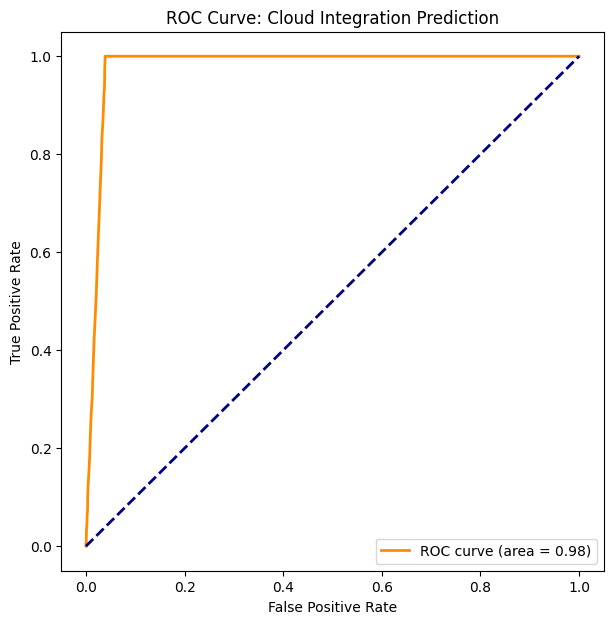

In [40]:
from sklearn.metrics import roc_curve, auc

# 3. CLASSIFICATION: High Cloud Integration Effectiveness
# Target: 1 if score > median, else 0
median_cloud = df['Cloud Integration Effectiveness'].median()
df['High_Cloud_Integration'] = (df['Cloud Integration Effectiveness'] > median_cloud).astype(int)

X_c = df.drop(['Cloud Integration Effectiveness', 'High_Cloud_Integration', 'High_Efficiency'], axis=1)
y_c = df['High_Cloud_Integration']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs = scaler_c.transform(X_test_c)

# RF for ROC Curve
rf_c = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_c, y_train_c)
y_probs = rf_c.predict_proba(X_test_c)[:, 1]

fpr, tpr, _ = roc_curve(y_test_c, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Cloud Integration Prediction')
plt.legend(loc='lower right')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


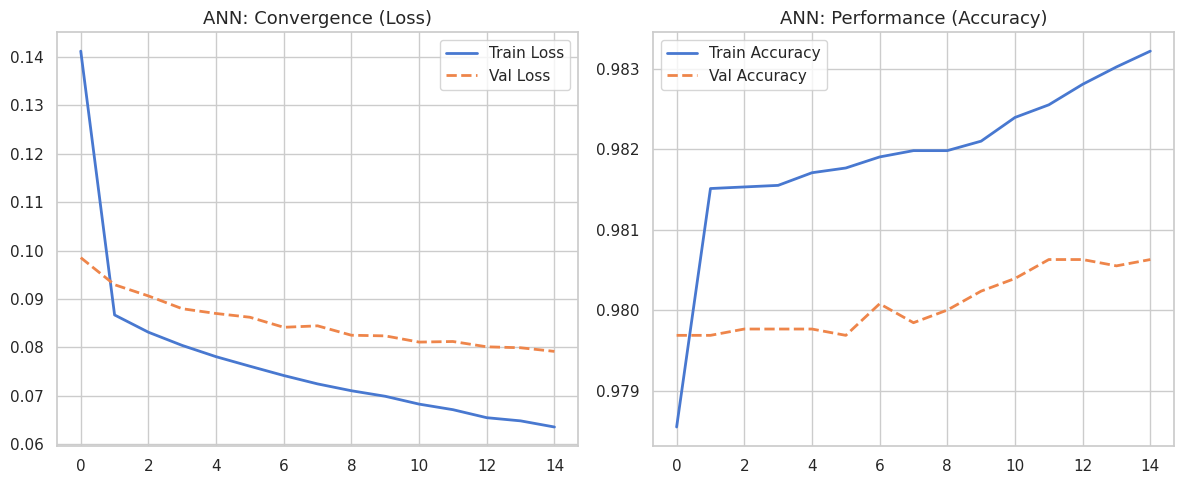

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 3. DEEP LEARNING VALIDATION (ANN)
# Training on the balanced, scaled dataset for maximum accuracy
ann_v = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_v = ann_v.fit(X_train_scaled, y_train, validation_split=0.2, epochs=15, verbose=0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_v.history['loss'], label='Train Loss', lw=2)
plt.plot(history_v.history['val_loss'], label='Val Loss', lw=2, linestyle='--')
plt.title('ANN: Convergence (Loss)', fontsize=13)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_v.history['accuracy'], label='Train Accuracy', lw=2)
plt.plot(history_v.history['val_accuracy'], label='Val Accuracy', lw=2, linestyle='--')
plt.title('ANN: Performance (Accuracy)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()